<a href="https://colab.research.google.com/github/mohsinatahmedlaboni/UW-BUET/blob/main/InMAP_trial_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -q https://go.dev/dl/go1.21.5.linux-amd64.tar.gz
!tar -C /usr/local -xzf go1.21.5.linux-amd64.tar.gz
import os
os.environ['PATH'] += ':/usr/local/go/bin'
!go version


go version go1.21.5 linux/amd64


In [2]:
!git clone https://github.com/INMAP-PAVITRA/InMAP-PAVITRA.git
%cd InMAP-PAVITRA

Cloning into 'InMAP-PAVITRA'...
remote: Enumerating objects: 16564, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 16564 (delta 4), reused 11 (delta 2), pack-reused 16551 (from 1)
Receiving objects: 100% (16564/16564), 100.22 MiB | 20.38 MiB/s, done.
Resolving deltas: 100% (3032/3032), done.
Updating files: 100% (18305/18305), done.
/content/InMAP-PAVITRA


In [3]:
!GO111MODULE=on go build ./cmd/inmap

go: downloading github.com/cenkalti/backoff v2.2.1+incompatible
go: downloading github.com/ctessum/geom v0.2.10
go: downloading github.com/ctessum/gobra v0.0.0-20180516235632-ddfa5eeb3017
go: downloading github.com/lnashier/viper v0.0.0-20180730210402-cc7336125d12
go: downloading github.com/skratchdot/open-golang v0.0.0-20160302144031-75fb7ed4208c
go: downloading github.com/spf13/cast v1.2.0
go: downloading github.com/spf13/cobra v0.0.3
go: downloading github.com/spf13/pflag v1.0.5
go: downloading gocloud.dev v0.23.0
go: downloading google.golang.org/grpc v1.37.0
go: downloading github.com/ctessum/polyclip-go v1.0.2-0.20200417141046-48e92ea36ddd
go: downloading gonum.org/v1/gonum v0.0.0-20191009222026-5d5638e6749a
go: downloading golang.org/x/net v0.7.0
go: downloading github.com/Knetic/govaluate v3.0.1-0.20171022003610-9aa49832a739+incompatible
go: downloading github.com/ctessum/atmos v0.0.0-20170526022537-cba69f7ca647
go: downloading github.com/ctessum/cdf v0.0.0-20181201011353-edced

In [11]:
!wget -q --show-progress "https://zenodo.org/records/3403934/files/evaldata_v1.6.1.zip?download=1" -O /content/evaldata_v1.6.1.zip

/content/evaldata_v 100%[===================>]   2.02G  2.21MB/s    in 15m 16s 


In [12]:
!unzip -q /content/evaldata_v1.6.1.zip -d /content/
!ls -la /content/evaldata_v1.6.1

total 2276556
drwxr-xr-x 6 root root       4096 Sep 10  2019 .
drwxr-xr-x 1 root root       4096 Jun 16 09:02 ..
drwxrwxr-x 2 root root       4096 Aug 22  2016 2005_emissions
-rw-r--r-- 1 root root   49368451 Feb 27  2014 annual_all_2005.csv
-rw-rw-r-- 1 root root   22662576 Aug 25  2017 census2013blckgrp.dbf
-rw-rw-r-- 1 root root        411 Aug 24  2017 census2013blckgrp.prj
-rw-rw-r-- 1 root root       2779 Aug 25  2017 census2013blckgrp_README.txt
-rw-rw-r-- 1 root root 1119525316 Aug 24  2017 census2013blckgrp.shp
-rw-rw-r-- 1 root root    1726748 Aug 24  2017 census2013blckgrp.shx
drwxr-x--- 4 root root       4096 Nov 15  2016 FuelScenarios
-rw-r----- 1 root root  727596732 Jun 28  2016 InMAPData_v1.2.0.ncf
-rw-r--r-- 1 root root  218190478 Sep 10  2019 InMAPData_v1.6.1.gob
drwxrwxr-x 2 root root       4096 Aug 22  2016 la_test
-rw-rw-r-- 1 root root     482152 Aug 25  2017 mortalityRates2013.dbf
-rw-rw-r-- 1 root root        411 Aug 25  2017 mortalityRates2013.prj
-rw-rw-r-- 1 r

In [13]:
!mkdir -p /content/InMAP-PAVITRA/nei2005

In [14]:
from google.colab import files
uploaded = files.upload()

Saving nei2005Config (2).toml to nei2005Config (2).toml


In [49]:
!pip install netCDF4 -q --break-system-packages 2>/dev/null
import netCDF4 as nc
ds = nc.Dataset('/content/evaldata_v1.6.1/la_test/inmapData.ncf')
print(ds)
print()
for v in ds.variables:
    print(v, ds.variables[v].shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.5 MB/s eta 0:00:00
<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    comment: InMAP meteorology and baseline chemistry data file
    x0: -2004000.0
    y0: -540000.0
    dx: 12000.0
    dy: 12000.0
    nx: 24
    ny: 20
    data_version: 1.2.0
    dimensions(sizes): x(24), y(20), z(27), xStagger(25), yStagger(21), zStagger(28)
    variables(dimensions): float32 aVOC(z, y, x), float32 gNH(z, y, x), float32 ParticleDryDep(z, y, x), float32 SO2DryDep(z, y, x), float32 M2d(z, y, x), float32 UAvg(z, y, xStagger), float32 VDeviation(z, yStagger, x), float32 aOrgPartitioning(z, y, x), float32 Temperature(z, y, x), float32 Sclass(z, y, x), float32 alt(z, y, x), float32 NHPartitioning(z, y, x), float32 Kxxyy(z, y, x), float32 Kzz(zStagger, y, x), float32 WAvg(zStagger, y, x), float32 bOrgPartitioning(z, y, x), float32 

In [50]:
config_content = '''InMAPData = "/content/evaldata_v1.6.1/la_test/inmapData.ncf"
VariableGridData = "/content/evaldata_v1.6.1/la_test/inmapVarGrid.gob"

EmissionsShapefiles = [
    "/content/evaldata_v1.6.1/la_test/testEmis.shp"
]

EmissionUnits = "tons/year"
HTTPAddress = ":8080"

OutputFile = "/content/InMAP-PAVITRA/laTest/laTest_output.shp"
LogFile = "/content/InMAP-PAVITRA/laTest/logfile.log"

[OutputVariables]
TotalPM25 = "PrimaryPM25 + pNH4 + pSO4 + pNO3 + SOA"
TotalPopD = "(exp(log(1.078)/10 * TotalPM25) - 1) * TotalPop * AllCause / 100000"
TotalPop = "TotalPop"
PrimPM25 = "PrimaryPM25"
PSO4 = "pSO4"
PNO3 = "pNO3"
PNH4 = "pNH4"
SOA = "SOA"
SOx = "SOx"
NH3 = "NH3"
NOx = "NOx"
BasePM25 = "BaselineTotalPM25"
WindSpeed = "WindSpeed"

[VarGrid]
VariableGridXo = -2004000.0
VariableGridYo = -540000.0
VariableGridDx = 12000.0
VariableGridDy = 12000.0
Xnests = [24]
Ynests = [20]
HiResLayers = 1
GridProj = "+proj=lcc +lat_1=33.000000 +lat_2=45.000000 +lat_0=40.000000 +lon_0=-97.000000 +x_0=0 +y_0=0 +a=6370997.000000 +b=6370997.000000 +to_meter=1"
PopDensityThreshold = 0.0055
PopThreshold = 40000.0
PopConcThreshold = 0.000000001

CensusFile = "/content/evaldata_v1.6.1/la_test/census2012.shp"
CensusPopColumns = ["TotalPop"]
PopGridColumn = "TotalPop"

MortalityRateFile = "/content/evaldata_v1.6.1/la_test/MortalityRate.shp"

[VarGrid.MortalityRateColumns]
AllCause = "TotalPop"
'''

with open('/content/laTestConfig.toml', 'w') as f:
    f.write(config_content)

print("Config updated")

Config updated


In [51]:
!mkdir -p /content/InMAP-PAVITRA/laTest
%cd /content/InMAP-PAVITRA
!./inmap run steady --config=/content/laTestConfig.toml

/content/InMAP-PAVITRA
2026/06/16 09:51:22 Parsing output variable expressions...
2026/06/16 09:51:22 Loading emissions shapefile: /content/evaldata_v1.6.1/la_test/testEmis.shp.
2026/06/16 09:51:22 Loading CTM data...
2026/06/16 09:51:22 Reading input data...
2026/06/16 09:51:22 Loading population and mortality rate data...
2026/06/16 09:51:25 Initializing model...
2026/06/16 09:51:38 Emission totals:
2026/06/16 09:51:38 gOrg, 143833.19698122775 μg/s
2026/06/16 09:51:38 pOrg, 0 μg/s
2026/06/16 09:51:38 PM2_5, 143833.19698122775 μg/s
2026/06/16 09:51:38 gNH, 118294.90281922402 μg/s
2026/06/16 09:51:38 pNH, 0 μg/s
2026/06/16 09:51:38 gS, 71991.36147066951 μg/s
2026/06/16 09:51:38 pS, 0 μg/s
2026/06/16 09:51:38 gNO, 43791.03455362866 μg/s
2026/06/16 09:51:38 pNO, 0 μg/s
2026/06/16 09:51:38 iteration 1     walltime=0.00363h  Δwalltime=  13s  timestep=20s  day=0.000236
2026/06/16 09:51:38 iteration 29    walltime=0.0038h  Δwalltime=0.021s  timestep=20s  day=0.00684
2026/06/16 09:51:40 itera

In [53]:
!ls -la /content/InMAP-PAVITRA/laTest/

total 220
drwxr-xr-x  2 root root   4096 Jun 16 09:55 .
drwxr-xr-x 17 root root   4096 Jun 16 09:48 ..
-rw-r--r--  1 root root 113249 Jun 16 09:55 laTest_output.dbf
-rw-r--r--  1 root root    431 Jun 16 09:55 laTest_output.prj
-rw-r--r--  1 root root  65380 Jun 16 09:55 laTest_output.shp
-rw-r--r--  1 root root   3940 Jun 16 09:55 laTest_output.shx
-rw-r--r--  1 root root  21025 Jun 16 09:55 logfile.log


In [54]:
import geopandas as gpd
gdf = gpd.read_file('/content/InMAP-PAVITRA/laTest/laTest_output.shp')
print(gdf.head())
print(gdf.columns.tolist())

   BasePM25           NH3       NOx      PNH4          PNO3          PSO4  \
0  1.249476  9.152777e-08  0.000005  0.000005  1.191030e-10  2.969869e-08   
1  1.282373  2.482015e-07  0.000014  0.000012  6.762336e-10  6.893921e-08   
2  1.335277  7.106975e-07  0.000038  0.000035  1.101455e-09  1.650991e-07   
3  1.426533  1.863951e-06  0.000098  0.000093  2.024761e-09  3.563432e-07   
4  1.541790  4.958968e-06  0.000256  0.000247  6.531570e-09  6.929786e-07   

   PrimPM25           SOA       SOx  TotalPM25  TotalPop     TotalPopD  \
0  0.000004  2.158235e-07  0.000005   0.000009  7.222826  2.927897e-09   
1  0.000012  3.766602e-07  0.000014   0.000025  0.000000  0.000000e+00   
2  0.000034  2.152329e-06  0.000038   0.000072  0.000000  0.000000e+00   
3  0.000089  2.295241e-06  0.000098   0.000185  0.000000  0.000000e+00   
4  0.000238  1.792862e-06  0.000256   0.000487  0.000000  0.000000e+00   

   WindSpeed                                           geometry  
0   4.030602  POLYGON ((-2

In [55]:
!pip install geopandas -q --break-system-packages 2>/dev/null
import geopandas as gpd

gdf = gpd.read_file('/content/InMAP-PAVITRA/laTest/laTest_output.shp')
print("Columns:", gdf.columns.tolist())
print()
print("Number of grid cells:", len(gdf))
print()
print(gdf[['TotalPM25', 'TotalPop', 'TotalPopD']].describe())

Columns: ['BasePM25', 'NH3', 'NOx', 'PNH4', 'PNO3', 'PSO4', 'PrimPM25', 'SOA', 'SOx', 'TotalPM25', 'TotalPop', 'TotalPopD', 'WindSpeed', 'geometry']

Number of grid cells: 480

          TotalPM25       TotalPop     TotalPopD
count  4.800000e+02     480.000000  4.800000e+02
mean   4.385687e-04   35262.373688  1.934549e-03
std    9.414985e-04  102987.107845  9.009524e-03
min    2.880303e-08       0.000000  0.000000e+00
25%    1.551790e-05       0.000000  0.000000e+00
50%    8.995863e-05      44.446306  2.232373e-08
75%    3.296119e-04    4995.330813  3.036618e-05
max    7.546752e-03  853304.286139  8.527945e-02


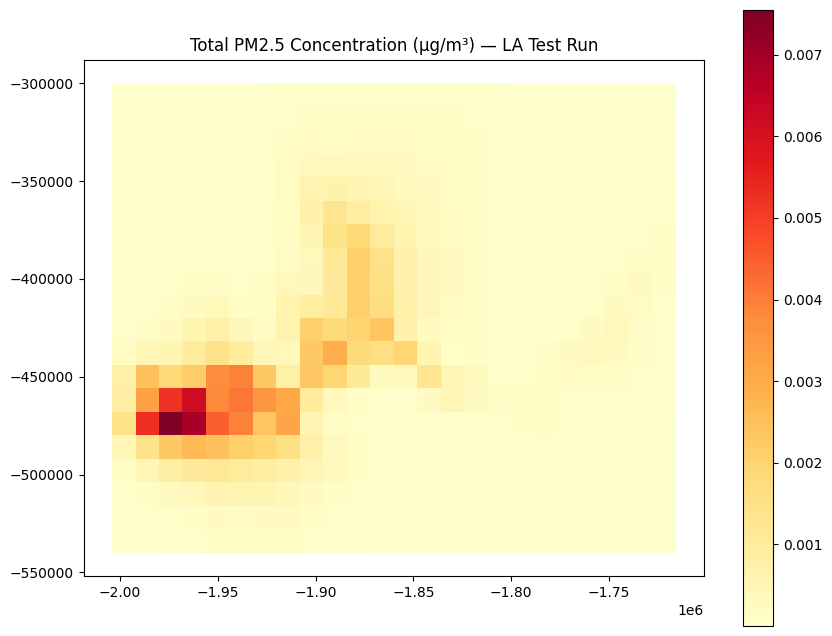

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column='TotalPM25', cmap='YlOrRd', legend=True, ax=ax)
ax.set_title('Total PM2.5 Concentration (μg/m³) — LA Test Run')
plt.show()

In [34]:
!cat /content/inmap_run.log
!ps aux | grep inmap

2026/06/16 09:30:41 Parsing output variable expressions...
2026/06/16 09:30:41 Loading emissions shapefile: /content/evaldata_v1.6.1/2005_emissions/bioFireEmis.shp.
2026/06/16 09:30:58 Loading emissions shapefile: /content/evaldata_v1.6.1/2005_emissions/Elevated.shp.
root       21982 61.7  5.5 2404016 737496 ?      Sl   09:30   1:33 ./inmap run steady --config=/content/nei2005Config.toml
root       22005 60.4  5.2 2336156 692576 ?      Sl   09:30   1:30 ./inmap run steady --config=/content/nei2005Config.toml
root       22117 54.1  4.1 2197824 546652 ?      Sl   09:30   1:08 ./inmap run steady --config=/content/nei2005Config.toml
root       22665  0.0  0.0   7376  3348 ?        S    09:32   0:00 /bin/bash -c ps aux | grep inmap
root       22667  0.0  0.0   6484  2352 ?        R    09:32   0:00 grep inmap


In [28]:
%cd /content/InMAP-PAVITRA
!nohup ./inmap run steady --config=/content/nei2005Config.toml > /content/inmap_run.log 2>&1 &

/content/InMAP-PAVITRA


In [52]:
!tail -20 /content/inmap_run.log
!ps aux | grep inmap
!free -h

2026/06/16 09:30:41 Parsing output variable expressions...
2026/06/16 09:30:41 Loading emissions shapefile: /content/evaldata_v1.6.1/2005_emissions/bioFireEmis.shp.
2026/06/16 09:30:58 Loading emissions shapefile: /content/evaldata_v1.6.1/2005_emissions/Elevated.shp.
root       28615  0.0  0.0   7376  3384 ?        S    09:55   0:00 /bin/bash -c ps aux | grep inmap
root       28617  0.0  0.0   6484  2424 ?        S    09:55   0:00 grep inmap
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       9.7Gi       2.0Mi       1.9Gi        11Gi
Swap:             0B          0B          0B


In [45]:
!ls -la /content/evaldata_v1.6.1/la_test

total 180272
drwxrwxr-x 2 root root     4096 Aug 22  2016 .
drwxr-xr-x 6 root root     4096 Sep 10  2019 ..
-rw-rw-r-- 1 root root  2261828 Feb 12  2016 census2012.dbf
-rw-rw-r-- 1 root root      446 Feb 12  2016 census2012.prj
-rw-rw-r-- 1 root root 21335404 Feb 12  2016 census2012.shp
-rw-rw-r-- 1 root root    84236 Feb 12  2016 census2012.shx
-rw-rw-r-- 1 root root  2357052 Aug 22  2016 inmapData.ncf
-rw-rw-r-- 1 root root  5559838 Aug 18  2016 inmapVarGrid.gob
-rw-rw-r-- 1 root root     3842 Feb 12  2016 MortalityRate.dbf
-rw-rw-r-- 1 root root      433 Feb 12  2016 MortalityRate.prj
-rw-rw-r-- 1 root root    58332 Feb 12  2016 MortalityRate.shp
-rw-rw-r-- 1 root root      220 Feb 12  2016 MortalityRate.shx
-rw-rw-r-- 1 root root      405 Feb 12  2016 testEmis.dbf
-rw-rw-r-- 1 root root      424 Feb 12  2016 testEmis.prj
-rw-rw-r-- 1 root root      892 Feb 12  2016 testEmis.shp
-rw-rw-r-- 1 root root      140 Feb 12  2016 testEmis.shx
-rw-rw-r-- 1 root root 76443268 Feb 12  2016 wr

In [43]:
!pkill -9 inmap

In [46]:
!pip install pyshp -q --break-system-packages 2>/dev/null
import shapefile
sf = shapefile.Reader("/content/evaldata_v1.6.1/la_test/census2012.shp")
print("Census fields:", [f[0] for f in sf.fields[1:]])

sf2 = shapefile.Reader("/content/evaldata_v1.6.1/la_test/MortalityRate.shp")
print("Mortality fields:", [f[0] for f in sf2.fields[1:]])

Census fields: ['Shape_Area', 'GISJOIN', 'TotalPop', 'WhiteNoLat', 'Black', 'Native', 'Asian', 'Other', 'Latino', 'Poverty', 'TwoXPov', 'BlackWlat', 'NativeWlat', 'AsianWlat', 'OtherWlat', 'BlackInc', 'NativeInc', 'AsianInc', 'WhiteInc', 'LatinoInc']
Mortality fields: ['key', 'STATE', 'COUNTY', 'GRASSRGB', 'AllCause', 'FIPS', 'Respirator']
